In [76]:
import pandas as pd
import time
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import tkinter as tk
from tkinter import filedialog
from AutomatedCellAnalysis.get_cell_image import get_cell_image
import sys

In [146]:
ROOT = tk.Tk()
ROOT.withdraw() #closes the tkinter window again. just a cleanup
ROOT.attributes('-topmost', True)
users_base_path = filedialog.askopenfilename(title="Choose a single well fit file", filetype=(('csv files', '*.csv'),("all files", "*.*")))
fileName=users_base_path.split("/")[-1] # next, determine the names of the corresponding _fit.csv and _tau.csv files
resultpath=users_base_path.rstrip(fileName)# the path without the filename
users_base_path = Path(users_base_path)
labelmap_pth = Path(users_base_path.parent.parent,'intensity_data',users_base_path.name[:-8]+'_I_mean_labelmap.tif')
meanimg_pth = Path(users_base_path.parent.parent,'intensity_data',users_base_path.name[:-8]+'_I_mean.tif')
wellName=fileName[0:len(fileName)-8]
resultfile = wellName+'_tau.csv' 
fitfile = wellName+'_fit.csv'
print(users_base_path)

D:\PhD_NKI\Projects\pde_screening\screening_data\Screening_Data_Analyzed\2019\11\07\chemical\results\B06_fit.csv


In [148]:
fit = pd.read_csv(Path(resultpath,fitfile))
condition=fit['condition'][0]
lifetimetraces = np.loadtxt(Path(resultpath,resultfile))
frameinterval = fit['frameinterval(s)'][0]
forskendpoint = True # or false, depending if you have chemical stimulation or caged-cAMP release
nroi = min(lifetimetraces.shape[0], max_nroi) #plot no more than max_nroi cells if they exist
ntime = lifetimetraces.shape[1]
fit_sel = fit[fit['breakdown_time(s)'] > 2]#these are conditions added by Rolf to reject some cells\n",
#fit_sel = fit_sel[fit_sel['error']==0]  #<<<<<<<<<<<<<< If you want to see all the data, then comment this out
print('There are '+ str(len(lifetimetraces)) +' individual cells in the FOV of well '+wellName)
print('There are '+ str(len(fit_sel)) +' individual cells that qualify as a good-enough fit')
print('Frameinterval was '+ str(round(frameinterval,1)) + ' seconds')

There are 175 individual cells in the FOV of well B06
There are 175 individual cells that qualify as a good-enough fit
Frameinterval was 4.9 seconds


In [149]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c))

175 traces were averaged


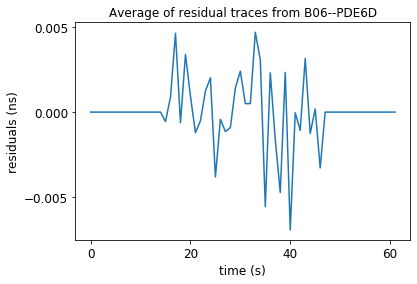

In [151]:
#trace_ids = [100, 101, 50] # somehow the highlighted cells start at trace-id nr. 1
#trace_ids = np.random.randint(1, len(lifetimetraces), size=max_nroi)
#trace_ids = list(range(len(lifetimetraces)))

trace_ids = list(range(1,len(fit_sel)))

i = 0
for trace_id in trace_ids:
    fit_vals= fit.loc[trace_id,:]
    fit_vals
    xdat = np.arange(0, ntime * frameinterval, frameinterval)
    ydat = lifetimetraces[trace_id]   
    yfit = fit_function(xdat,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown_time(s)'],fit_vals['midpoint(s)'])
    #print(wellName,"  ", condition,"  ", "Cell ", trace_id,  '       n_x =', len(xdat), '  n_y =', len(ydat),'  n_yfit =', len(yfit))
    
    # find the fit-range
    fitrange = np.zeros(shape=2, dtype=int)
    mean_trace = np.mean(lifetimetraces, axis=0)
    
    d_mean_trace = np.diff(mean_trace)
    fitrange[0] = np.argmax(mean_trace[0:int(150 / frameinterval)])  # maximum in the first 150 seconds
    fitrange[1] = ntime
    if forskendpoint:
        # 3 frames before maximum increase after peak.
        fitrange[1] = fitrange[0] + np.argmax(d_mean_trace[fitrange[0]:]) - 1
    
    xdat_selected = xdat[fitrange[0]:fitrange[1]]
    ydat_selected = ydat[fitrange[0]:fitrange[1]]
    yfit_selected = yfit[fitrange[0]:fitrange[1]]
    
    yresid = ydat - yfit #generate residuals but only for fit region
    yresid[0:fitrange[0]]=0
    yresid[fitrange[1]:len(yresid)]=0    
    
    if i == 0:
        cols = len(yresid)                         #defining the number of rows to be made in the array
        rows = len(fit_sel)                        #defining the number of columns to be made in the array
        yresid_values = np.zeros((rows,cols))      #new array is made, filled with zeroes 
        
    
    yresid_values[i,:] = yresid                    #keeps filling the array as the loop runs with yresid values of every cell/trace
    i = i+1
    
  
yresid_values = yresid_values[~np.isnan(yresid_values).any(axis=1)]         #removes the entire row if a NaN is spotted
yresid_avg = np.mean(yresid_values, axis=0)                                 #calculates the average of all cells/traces analysed
plt.plot(yresid_avg)

#plot tuning
plt.title('Average of residual traces from ' + wellName+ '--' +condition, fontsize = 12) 
plt.xlabel('time (s)', fontsize = 12)
plt.ylabel('residuals (ns)', fontsize = 12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
print(str(len(fit_sel)) +' traces were averaged')

    

In [104]:
np.set_printoptions(threshold=np.inf)
new_array


array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  9.14077603e-03,
         3.53132164e-03, -2.88344159e-02,  5.68323073e-03,
         3.86946957e-02,  2.85474043e-02, -1.68180505e-01,
        -3.21512789e-02,  1.56823037e-01,  6.13765640e-02,
        -8.40346037e-02,  1.54493668e-01, -1.45089911e-01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00

In [68]:
#new_array = new_array.dropna(how='any')
new_array.dropna(subset=['new_array'], inplace = True)
#new_array = new_array[~np.isnan(new_array)]    
#c = np.mean(new_array, axis=0) 
#plt.plot(c)


AttributeError: 'numpy.ndarray' object has no attribute 'dropna'

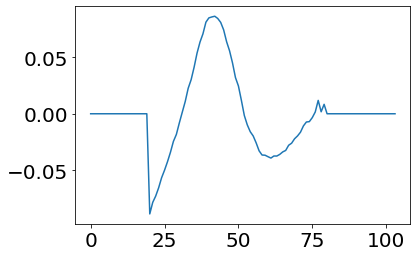

In [74]:
new_array = new_array[~np.isnan(new_array).any(axis=1)]
np.isnan(new_array)
c = np.mean(new_array, axis=0) 
plt.plot(c)

In [64]:
np.set_printoptions(threshold=np.inf)
new_array

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -4.78407760e-02,
        -6.01938225e-02, -9.01169225e-02, -8.84643846e-02,
        -6.27873671e-02, -6.44547314e-02, -4.57088032e-02,
        -5.07081991e-02, -2.74437073e-02, -2.64650172e-02,
         5.12332871e-03, -9.08761825e-03,  4.20379521e-02,
         4.13221895e-02,  7.32527572e-02,  6.57278195e-02,
         9.37710515e-02,  6.01797805e-02,  7.49503720e-02,
         7.99104589e-02,  5.41069285e-02,  1.02959417e-01,
         1.05119382e-01,  7.36342911e-02,  5.55502396e-02,
         8.18695636e-02,  4.20622790e-02,  3.04410991e-02,
        -4.48959814e-04, -4.04118630e-03, -3.66906522e-0

In [46]:
c

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0., nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.])

In [86]:
yresid.shape


(104,)

In [20]:

cols = len(yresid)
rows = len(fit_sel)
new_array = np.zeros((rows,cols))


In [15]:
new_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [21]:
rows

663

In [22]:
cols

104

In [28]:
new_array[1,:] = yresid

In [24]:
new_array


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [29]:
new_array[1,:]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.00892346, -0.00161684,  0.00056166,  0.01403534,  0.01212032,
       -0.00610413,  0.02978649,  0.01022322,  0.0120427 ,  0.00063664,
       -0.01764208, -0.0295472 , -0.01453081, -0.02378174,  0.00208064,
       -0.03362782,  0.00989866,  0.01130676, -0.00997864,  0.01963844,
        0.01050688, -0.01059788,  0.02984326,  0.00120461,  0.02408304,
       -0.03912991,  0.0227239 , -0.01020872, -0.03264356, -0.03395818,
       -0.0323739 , -0.00994987, -0.02145032, -0.02620917, -0.004839  ,
        0.00390844, -0.00282016,  0.01303716,  0.02235655, -0.04947418,
        0.00852368, -0.00337296, -0.02287003, -0.00130461,  0.0150824 ,
       -0.04140058,  0.01595005, -0.01176485,  0.02307306, -0.01

In [31]:
new_array


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [39]:
new_array[5,:]


array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.14980765, -0.14482733, -0.11288829, -0.10952186, -0.11074626,
       -0.10552118, -0.08456095, -0.05807505, -0.0569181 , -0.06999642,
       -0.04747703, -0.03023327, -0.00565269,  0.00233057,  0.02337683,
        0.03135191,  0.0178795 ,  0.05472621,  0.05368932,  0.07304712,
        0.06413047,  0.0924882 ,  0.09055908,  0.09736005,  0.11380227,
        0.1324516 ,  0.11937592,  0.14453841,  0.12698856,  0.11328632,
        0.14494951,  0.15712776,  0.12149042,  0.12854406,  0.13961393,
        0.12396187,  0.09368603,  0.09906234,  0.09388362,  0.07283809,
        0.04776491,  0.06434258,  0.00337522,  0.02892908,  0.00774446,
       -0.003906  , -0.04085569, -0.05711511, -0.05023589, -0.04

In [38]:
new_array[60,:]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [34]:
new_array[1,:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0.])

In [79]:
i


663

In [44]:
trace_ids


(1, 663)